# 3. Explore the wine dataset

Explore distributions, price, geography, grapes, and ratings using the historical cleaned and inferred datasets. Imputation precedes this notebook because the original EDA consumes inferred values.

**Recorded outputs:** figures and metrics are preserved from the course project. They have not been regenerated with the reorganized code. Datasets and fitted models are not included.


In [ ]:
from pathlib import Path
import sys

# Locate the checkout whether Jupyter starts in the root or notebooks/.
PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "pyproject.toml").is_file() and (p / "src/wine_quality").is_dir()
)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
from wine_quality.paths import RAW_DATA, INTERIM_DATA, PROCESSED_DATA, FIGURES

for folder in (FIGURES / "eda", FIGURES / "imputation", FIGURES / "models" / "shap"):
    folder.mkdir(parents=True, exist_ok=True)


In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations

from wine_quality.preprocess import calc_std

sns.set_theme("notebook", "darkgrid")

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
df = pd.read_json(PROCESSED_DATA / "wines_inferred.json")
grapes_df = pd.read_csv(INTERIM_DATA / "grapes_merged.csv")
grapes_dict = grapes_df.set_index("id")["name"].to_dict() # get id : grape_name dict


df["type"] = df["type"].replace({"spark":"sparkling", "fortif":"fortified"})
df_old = pd.read_json(INTERIM_DATA / "wines_merged3.json")
df = df[df["n_rating"] > 0]
df_old = df_old[df_old["n_rating"] > 0]

df = df[(df["id"] != 142522005) & (df["id"] != 144353810)] # distillates

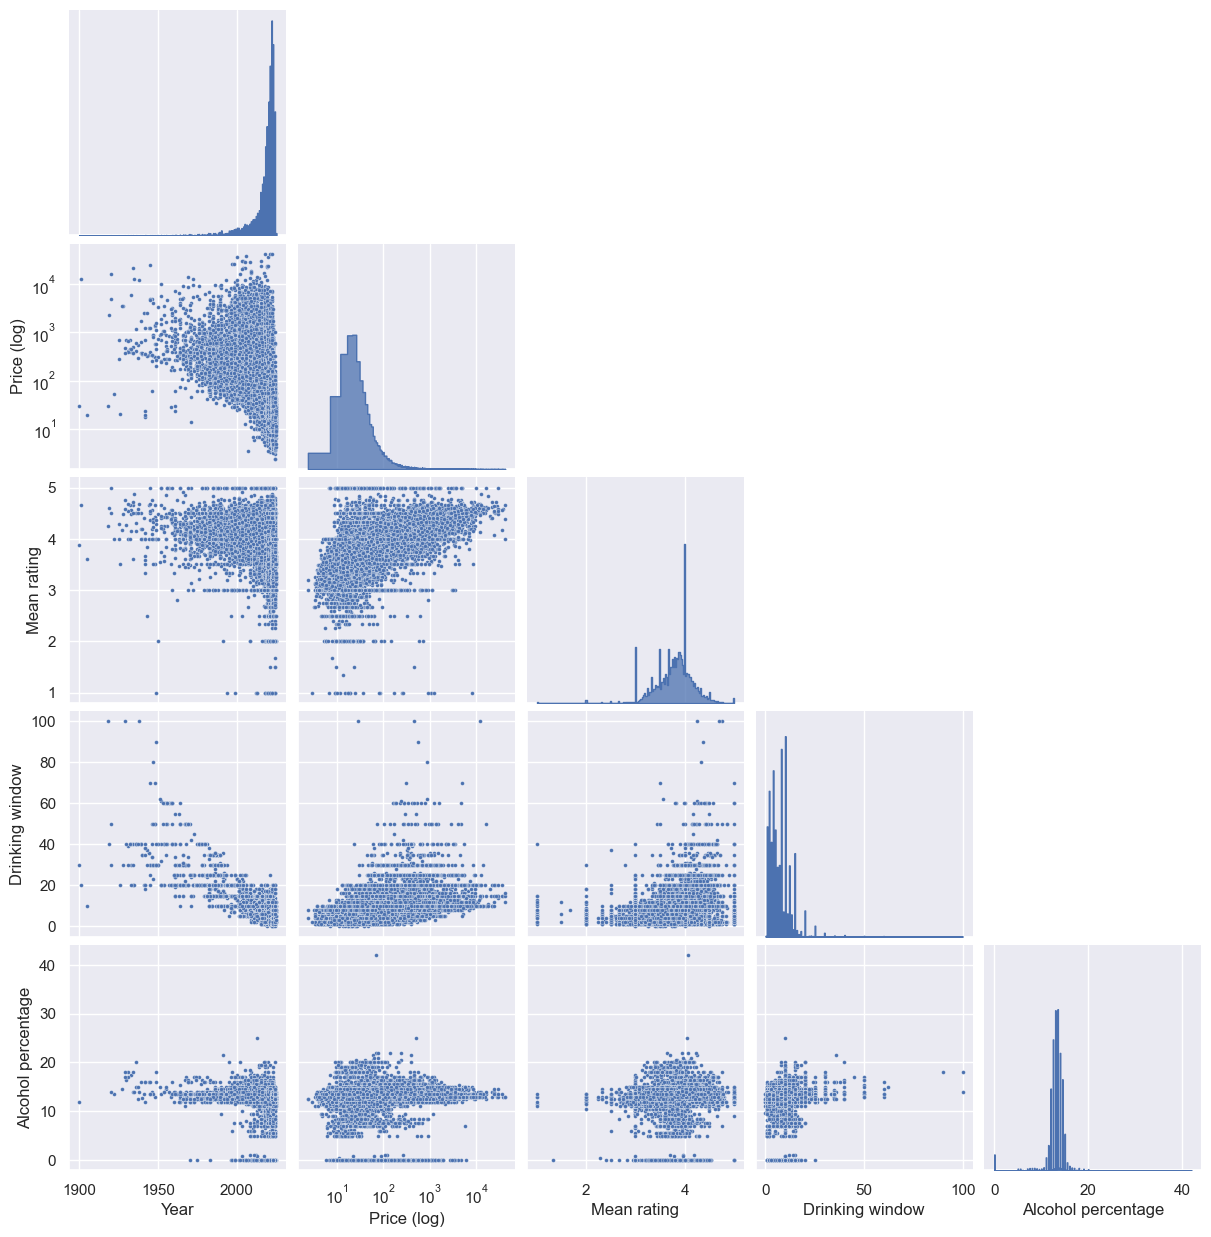

In [67]:

df_plot = df_old[["price", "mean_rating", "alcohol", "window_start_year", "window_end_year", "year"]].copy()
df_plot["drinking_window"] = df_plot["window_end_year"] - df_plot["window_start_year"]
df_plot = df_plot.drop(columns=["window_start_year", "window_end_year"])
df_plot = df_plot.rename(columns={"price":"Price (log)",
                                  "mean_rating":"Mean rating",
                                  "drinking_window":"Drinking window",
                                  "alcohol":"Alcohol percentage",
                                  "year":"Year"})

df_plot = df_plot[['Year', 'Price (log)', 'Mean rating', 'Drinking window', 'Alcohol percentage']]
g=sns.pairplot(df_plot, plot_kws={"s":8}, corner=True, diag_kws={"element":"step"})
g.axes[1, 0].set_yscale('log')
g.axes[2, 1].set_xscale('log')
g.figure.savefig(FIGURES / "eda/pairplot.jpg", dpi=300, bbox_inches="tight")

In [40]:
stars = np.arange(1, 6)

stats_ratings = df["ratings_distribution"].apply(lambda row : calc_std(row, stars))
stats_ratings = stats_ratings.rename(columns={0 : "median", 1 : "mean", 2 : "std"})

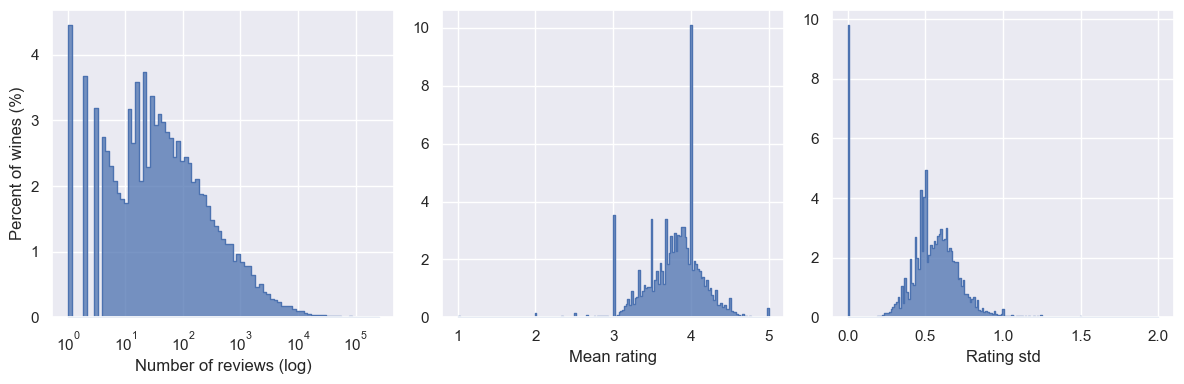

In [41]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax=sns.histplot(df["n_rating"], ax=ax1, log_scale=True, stat="percent", element="step")
sns.histplot(stats_ratings["mean"], ax=ax2, stat="percent", element="step")
sns.histplot(stats_ratings["std"], ax=ax3, stat="percent", element="step")

ax1.set_xlabel("Number of reviews (log)")
ax1.set_ylabel("Percent of wines (%)")

ax2.set_xlabel("Mean rating")
ax3.set_xlabel("Rating std")

ax1.set_ylabel("Percent of wines (%)")
ax2.set_ylabel("")
ax3.set_ylabel("")

plt.tight_layout()

fig.savefig(FIGURES / "eda/rating_mean_std_number.jpg", bbox_inches="tight", dpi=300)

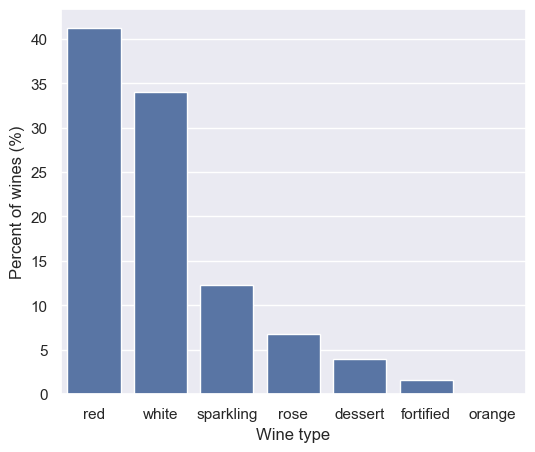

In [8]:
# Type distribution
fig=plt.figure(figsize=(6, 5))
ax=sns.barplot(df["type"].value_counts(normalize=True) * 100)
ax.set_xlabel("Wine type")
ax.set_ylabel("Percent of wines (%)")

fig.savefig(FIGURES / "eda/type_distr.jpg", bbox_inches="tight", dpi=300)

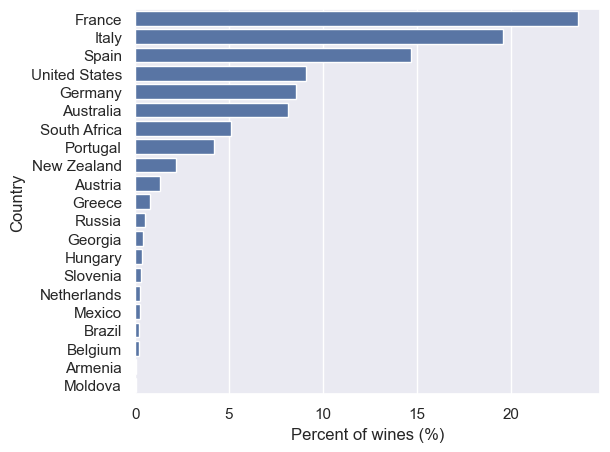

In [9]:
fig=plt.figure(figsize=(6, 5))
ax=sns.barplot(data=(df["country"].value_counts(normalize=True) * 100).reset_index(),
            x="proportion", y="country")
ax.set_ylabel("Country")
ax.set_xlabel("Percent of wines (%)")

fig.savefig(FIGURES / "eda/country_distr.jpg", bbox_inches="tight", dpi=300)

### Region

1395


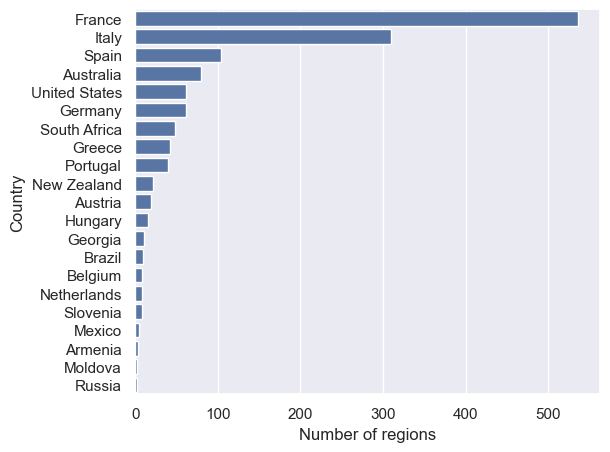

In [10]:
print(df["region_name"].nunique())

fig=plt.figure(figsize=(6, 5))
#wineries_count = (df.groupby("country")["winery_name"].nunique() / df["winery_name"].nunique() * 100).reset_index()
wineries_count = df.groupby("country")["region_name"].nunique().reset_index()
# wineries_count = df.groupby("country")["winery_name"].nunique().reset_index()
ax=sns.barplot(data=wineries_count.sort_values("region_name", ascending=False),
            x="region_name", y="country")
ax.set_ylabel("Country")
ax.set_xlabel("Number of regions")
fig.savefig(FIGURES / "eda/regions_per_country.jpg", bbox_inches="tight", dpi=300)

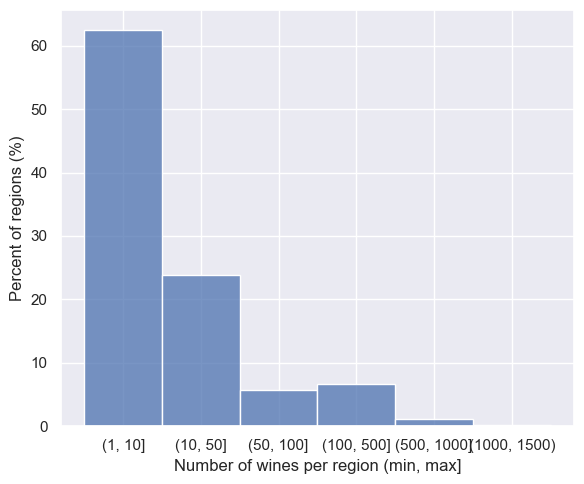

In [11]:
# wineries prices : count, means, std
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

counts = df.groupby("region_name")["id"].nunique()
bin_labels = ['(1, 10]', '(10, 50]', '(50, 100]', '(100, 500]', '(500, 1000]', '(1000, 1500)']
data_binned = pd.cut(counts, bins=[0, 10, 50, 100, 500, 1000, 1500], labels=bin_labels)

sns.histplot(data_binned, ax=ax, stat="percent")
ax.set_ylabel("Percent of regions (%)")
ax.set_xlabel("Number of wines per region (min, max]")

plt.tight_layout()

fig.savefig(FIGURES / "eda/regions_n_wines.jpg", bbox_inches="tight", dpi=300)

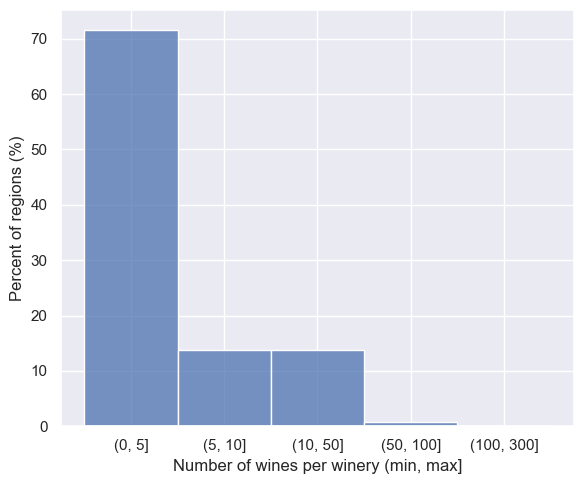

In [12]:
# wineries prices : count, means, std
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

counts = df.groupby("winery_name")["id"].nunique()
bin_labels = ['(0, 5]', '(5, 10]', '(10, 50]', '(50, 100]', '(100, 300]']
data_binned = pd.cut(counts, bins=[0, 5, 10, 50, 100, 300], labels=bin_labels)

sns.histplot(data_binned, ax=ax, stat="percent")
ax.set_ylabel("Percent of regions (%)")
ax.set_xlabel("Number of wines per winery (min, max]")

plt.tight_layout()

fig.savefig(FIGURES / "eda/wineries_n_wines.jpg", bbox_inches="tight", dpi=300)

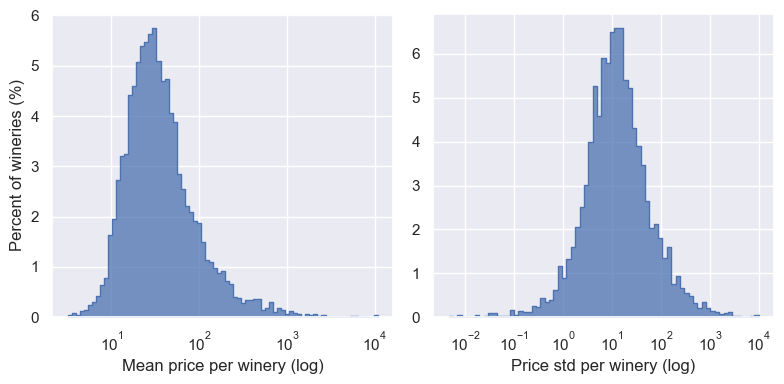

In [13]:
# wineries prices : count, means, std
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

counts = df.groupby("winery_name")["id"].nunique()
means = df.groupby("winery_name")["price"].mean()
stds = df.groupby("winery_name")["price"].std()

bin_labels = ['(0, 5]', '(5, 10]', '(10, 50]', '(50, 100]', '(100, 300]']
data_binned = pd.cut(counts, bins=[0, 5, 10, 50, 100, 300], labels=bin_labels)

#sns.histplot(data_binned, ax=ax1, stat="percent")

#sns.histplot(counts, ax=ax1,  bins=[0, 10, 50, 100], stat="percent", element="step")
sns.histplot(means, log_scale=True, ax=ax1, stat="percent", element="step")
sns.histplot(stds, log_scale=True, ax=ax2, stat="percent", element="step")

ax1.set_ylabel("Percent of wineries (%)")
ax2.set_ylabel("")
#ax3.set_ylabel("")

#ax1.set_xlabel("Number of wines per winery (min, max]")
ax1.set_xlabel("Mean price per winery (log)")
ax2.set_xlabel("Price std per winery (log)")

plt.tight_layout()

fig.savefig(FIGURES / "eda/wineries_stats.jpg", bbox_inches="tight", dpi=300)

### Winery

8018


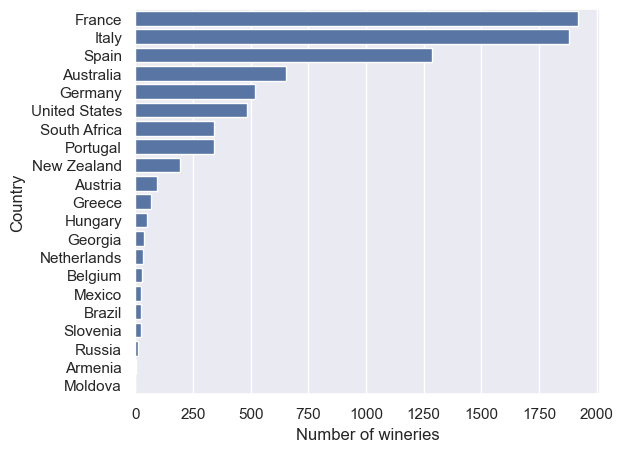

In [14]:
print(df["winery_name"].nunique())

fig=plt.figure(figsize=(6, 5))
#wineries_count = (df.groupby("country")["winery_name"].nunique() / df["winery_name"].nunique() * 100).reset_index()
wineries_count = df.groupby("country")["winery_name"].nunique().reset_index()
# wineries_count = df.groupby("country")["winery_name"].nunique().reset_index()
ax=sns.barplot(data=wineries_count.sort_values("winery_name", ascending=False),
            x="winery_name", y="country")
ax.set_ylabel("Country")
ax.set_xlabel("Number of wineries")

fig.savefig(FIGURES / "eda/wineries_per_country.jpg", bbox_inches="tight", dpi=300)

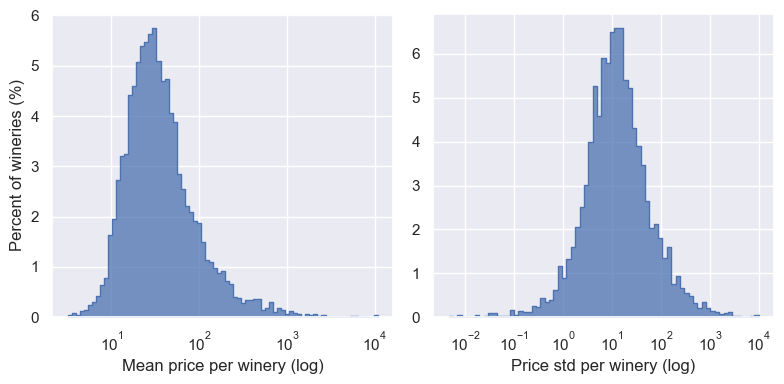

In [15]:
# wineries prices : count, means, std
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

counts = df.groupby("winery_name")["id"].nunique()
means = df.groupby("winery_name")["price"].mean()
stds = df.groupby("winery_name")["price"].std()

bin_labels = ['(1, 5]', '(5, 10]', '(10, 50]', '(50, 100]', '(100, 300]']
data_binned = pd.cut(counts, bins=[0, 5, 10, 50, 100, 300], labels=bin_labels)

#sns.histplot(data_binned, ax=ax1, stat="percent")

#sns.histplot(counts, ax=ax1,  bins=[0, 10, 50, 100], stat="percent", element="step")
sns.histplot(means, log_scale=True, ax=ax1, stat="percent", element="step")
sns.histplot(stds, log_scale=True, ax=ax2, stat="percent", element="step")

ax1.set_ylabel("Percent of wineries (%)")
ax2.set_ylabel("")
#ax3.set_ylabel("")

#ax1.set_xlabel("Number of wines per winery")
ax1.set_xlabel("Mean price per winery (log)")
ax2.set_xlabel("Price std per winery (log)")

plt.tight_layout()

fig.savefig(FIGURES / "eda/wineries_stats.jpg", bbox_inches="tight", dpi=300)

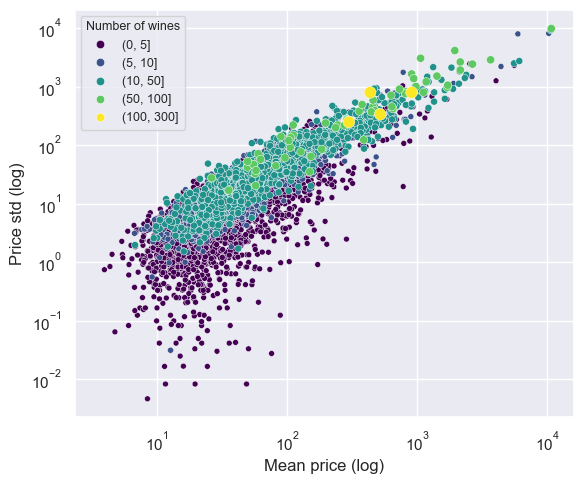

In [17]:
stats = pd.DataFrame(data={"mean":means.values, "std":stds.values, "winery":means.index, "count":counts.values})
stats["bucket"] = pd.cut(stats["count"], bins=[0, 5, 10, 50, 100, 300], labels=False)
size_map = {0: 5, 1: 10, 2: 50, 3: 100, 4: 300}
stats["size_mapped"] = stats["bucket"].map(size_map)

fig=plt.figure(figsize=(6, 5))
# # Scatterplot with size and hue based on the same bucket
ax = sns.scatterplot(
    data=stats.sort_values("size_mapped", ascending=True),
    x="mean",
    y="std",
    size="size_mapped",
    hue="bucket",
    palette="viridis",
    alpha=1,
)
ax.set_xscale("log")
ax.set_yscale("log")

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles=handles[1:6], labels=['(0, 5]', '(5, 10]', '(10, 50]', '(50, 100]', '(100, 300]'], title="Number of wines",
          fontsize=9, title_fontsize=9)

ax.set_xlabel("Mean price (log)")
ax.set_ylabel("Price std (log)")

plt.tight_layout()
fig.savefig(FIGURES / "eda/wineries_price_std.jpg", bbox_inches="tight", dpi=300)

# ax.set_title("Price per winery")

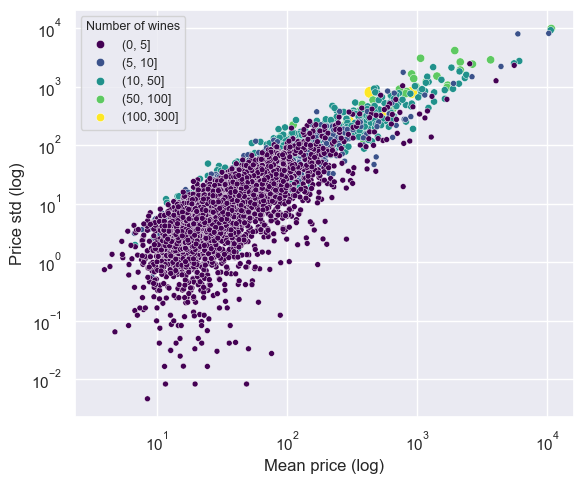

In [18]:
stats = pd.DataFrame(data={"mean":means.values, "std":stds.values, "winery":means.index, "count":counts.values})
stats["bucket"] = pd.cut(stats["count"], bins=[0, 5, 10, 50, 100, 300], labels=False)
size_map = {0: 5, 1: 10, 2: 50, 3: 100, 4: 300}
stats["size_mapped"] = stats["bucket"].map(size_map)

fig = plt.figure(figsize=(6, 5))
# # Scatterplot with size and hue based on the same bucket
ax = sns.scatterplot(
    data=stats.sort_values("size_mapped", ascending=False),
    x="mean",
    y="std",
    size="size_mapped",
    hue="bucket",
    palette="viridis",
    alpha=1,
)
ax.set_xscale("log")
ax.set_yscale("log")

handles, labels = ax.get_legend_handles_labels()

ax.legend(handles=handles[1:6], labels=['(0, 5]', '(5, 10]', '(10, 50]', '(50, 100]', '(100, 300]'], title="Number of wines",
          fontsize=9, title_fontsize=9)

ax.set_xlabel("Mean price (log)")
ax.set_ylabel("Price std (log)")

plt.tight_layout()
fig.savefig(FIGURES / "eda/wineries_price_std_inv.jpg", bbox_inches="tight", dpi=300)

# ax.set_title("Price per winery")

### Taste

In [19]:
tastes = df_old[df_old["alcohol"] < 30][['intensity', 'sweetness', 'acidity', 'tannin', 'fizziness', 'type']]
tastes = tastes.melt(value_vars=['intensity', 'sweetness', 'acidity', 'tannin', 'fizziness'],
            var_name="taste", value_name="value", id_vars=["type"])

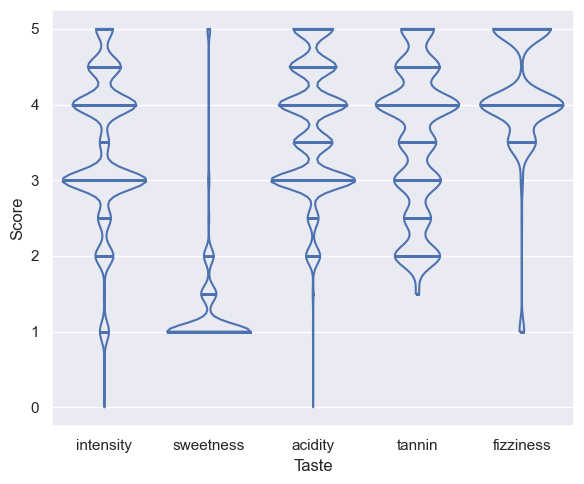

In [20]:
fig=plt.figure(figsize=(6, 5))
ax=sns.violinplot(tastes, y="value", x="taste", fill=False, inner="stick", density_norm='width', cut=0)
ax.set_xlabel("Taste")
ax.set_ylabel("Score")
plt.tight_layout()

fig.savefig(FIGURES / "eda/tastes_fulldf.jpg",  bbox_inches="tight",dpi=300)

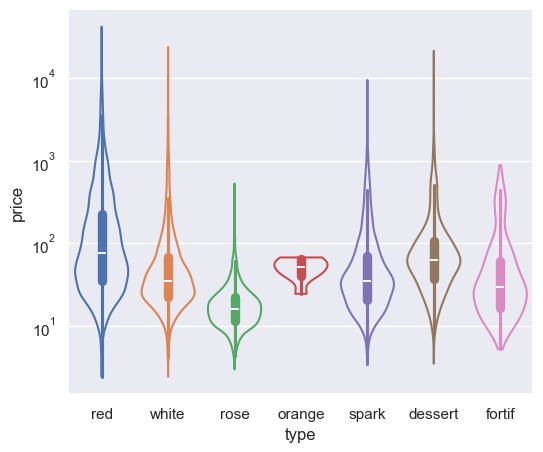

In [21]:
fig=plt.figure(figsize=(6, 5))
sns.violinplot(df_old, x="type", y="price", log_scale=True, fill=False, hue="type",  density_norm='width', cut=0)
ax.set_ylabel("Price (log)")
ax.set_xlabel("Wine type")
fig.savefig(FIGURES / "eda/type_price.jpg", bbox_inches="tight", dpi=300)

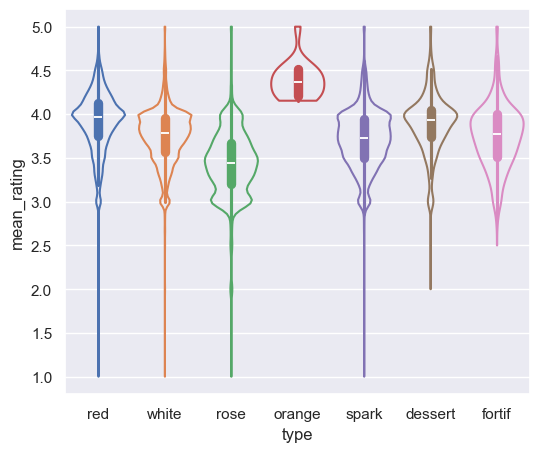

In [23]:
fig=plt.figure(figsize=(6, 5))
sns.violinplot(df_old, x="type", y="mean_rating", fill=False, hue="type",  density_norm='width', cut=0)
ax.set_ylabel("Mean rating")
ax.set_xlabel("Wine type")
fig.savefig(FIGURES / "eda/type_rating.jpg", bbox_inches="tight", dpi=300)

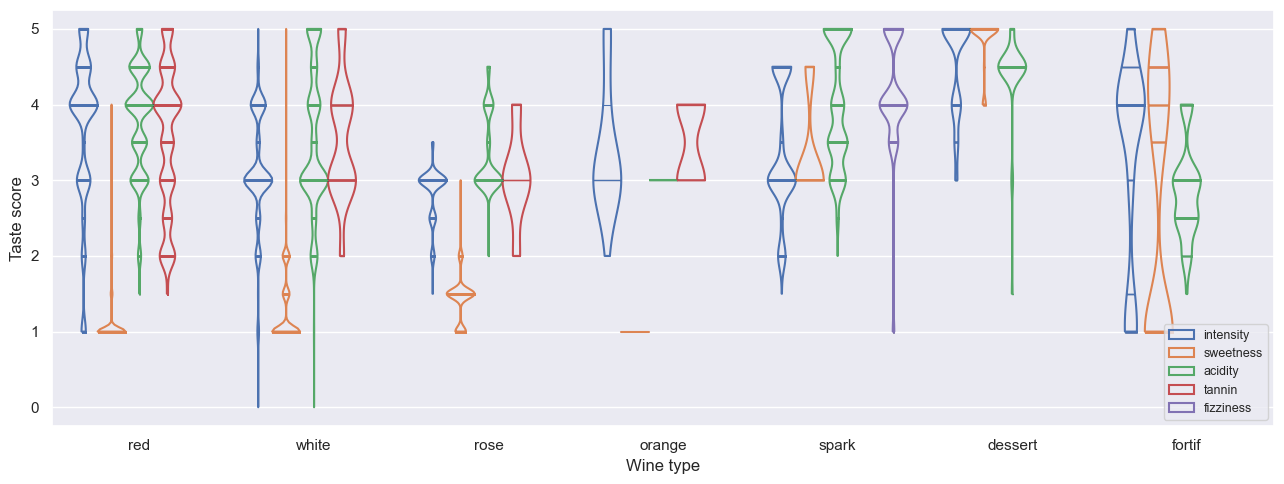

In [24]:
fig=plt.figure(figsize=(13, 5))
ax=sns.violinplot(tastes, y="value", x="type", fill=False, hue="taste", inner="stick", common_norm=False, density_norm='width', cut=0)

plt.legend(loc="lower right", fontsize=9)
ax.set_xlabel("Wine type")
ax.set_ylabel("Taste score")
plt.tight_layout()

fig.savefig(FIGURES / "eda/tastes_per_type.jpg", bbox_inches="tight", dpi=300)

### Price

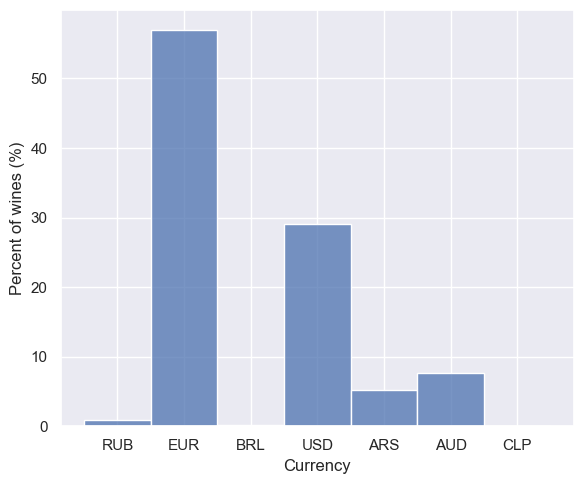

In [25]:
fig=plt.figure(figsize=(6, 5))
ax=sns.histplot(df["base_currency"], stat="percent")
ax.set_ylabel("Percent of wines (%)")
ax.set_xlabel("Currency")
plt.tight_layout()
fig.savefig(FIGURES / "eda/currencies_distr.jpg", bbox_inches="tight", dpi=300)

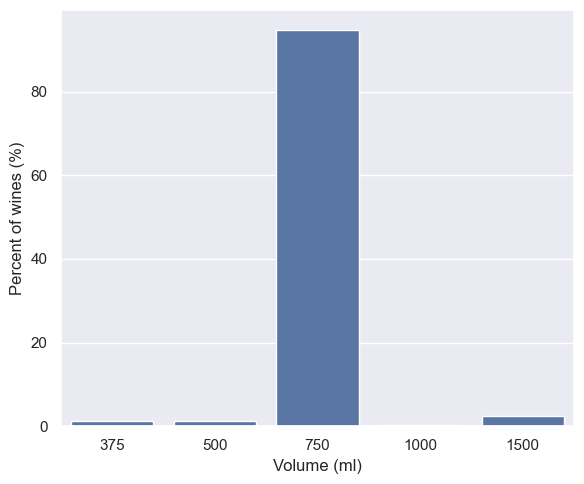

In [26]:
fig=plt.figure(figsize=(6, 5))
ax=sns.barplot(df["base_volume"].dropna().astype(int).value_counts(normalize=True) * 100)
ax.set_ylabel("Percent of wines (%)")
ax.set_xlabel("Volume (ml)")
plt.tight_layout()
fig.savefig(FIGURES / "eda/volume_distr.jpg", bbox_inches="tight", dpi=300)

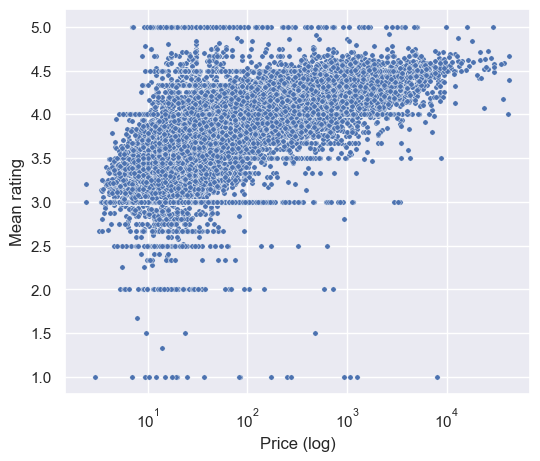

In [27]:
fig=plt.figure(figsize=(6, 5))

ax = sns.scatterplot(data=df, x="price", y="mean_rating", s=15)
ax.set_xscale("log")

ax.set_ylabel("Mean rating")
ax.set_xlabel("Price (log)")

fig.savefig(FIGURES / "eda/rating_price_joint.jpg", bbox_inches="tight", dpi=300)

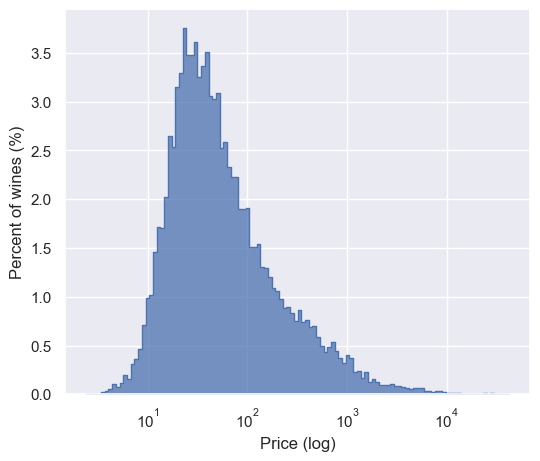

In [28]:
fig=plt.figure(figsize=(6, 5))
ax=sns.histplot(df["price"], log_scale=True, element="step", stat="percent")
ax.set_ylabel("Percent of wines (%)")
ax.set_xlabel("Price (log)")
fig.savefig(FIGURES / "eda/price_distr.jpg", bbox_inches="tight", dpi=300)

### Foods, grapes

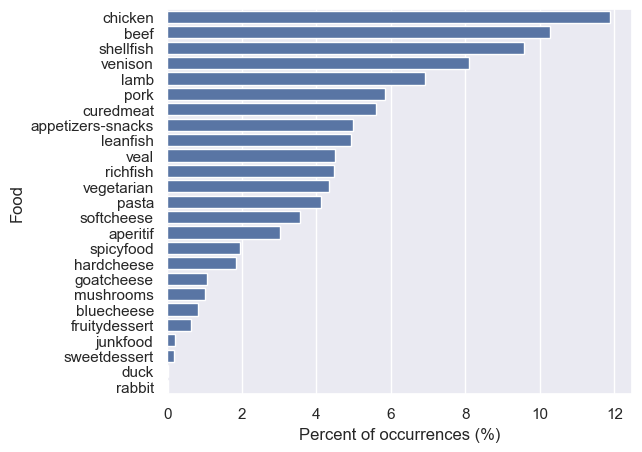

In [29]:
food_mapping = {
    "japanese" : "junkfood",
    "asian" : "junkfood",
    "risotto" : "pasta"
}

fig = plt.figure(figsize=(6, 5))
foods = df["food"].explode().reset_index()
foods["food"] = foods["food"].replace(food_mapping)
foods_counts = (foods.value_counts("food", normalize=True) * 100).reset_index()
ax=sns.barplot(data=foods_counts, x="proportion", y="food")

ax.set_ylabel("Food")
ax.set_xlabel("Percent of occurrences (%)")

fig.savefig(FIGURES / "eda/food_distr.jpg", bbox_inches="tight", dpi=300)

<Axes: xlabel='type', ylabel='food'>

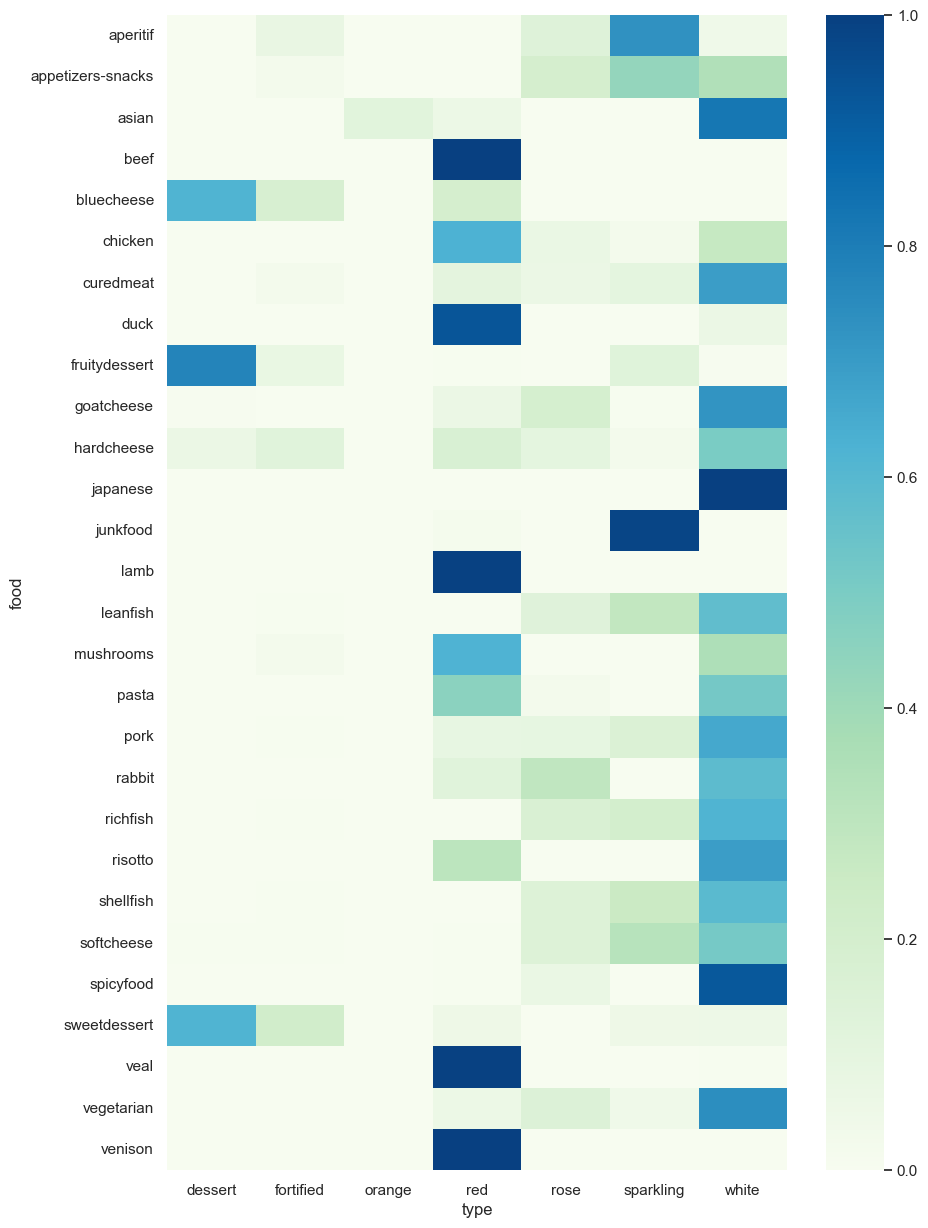

In [59]:
foods = df[["food", "type"]].explode("food").reset_index()
#foods["food"] = foods["food"].replace(food_mapping)

table = pd.crosstab(foods["food"], foods["type"]) 
table = table.div(table.sum(axis=1), axis=0)

fig=plt.figure(figsize=(10, 15))
sns.heatmap(table, cmap="GnBu", annot=False)
#fig.savefig(FIGURES / "eda/type-food-pairing.jpg", bbox_inches="tight", dpi=300)

In [60]:
foods

,index,food,type
0,0,beef,red
1,0,chicken,red
2,0,vegetarian,red
3,0,hardcheese,red
4,1,duck,red
...,...,...,...
181320,46872,mushrooms,red
181321,46873,NaN,dessert
181322,46874,beef,red
181323,46874,chicken,red


In [ ]:
from itertools import combinations

def build_coocc(df, col):
    def inv(row):
        return pd.Series([row["pair"][::-1], row["count"]])
    
    d = {c : 0 for c in combinations(np.sort(df[col].explode().dropna().unique()), 2)}
    for lst in df[col].dropna():
        for c in combinations(sorted([v for v in lst if v is not None]), 2):
            if c in d:
                d[c] += 1
            else:
                print(c)

    coocc = pd.DataFrame(data={"pair":d.keys(), "count":d.values()})
    coocc_inv = coocc.apply(inv, axis=1).rename(columns={0 : "pair", 1 : "count"})
    return pd.concat([coocc, coocc_inv], axis=0)


In [ ]:
coocc = build_coocc(df[["food"]], "food")
coocc = coocc.join(coocc["pair"].apply(pd.Series).rename(columns={0:"food 1", 1:"food 2"}))
coocc


('sweetdessert', 'sweetdessert')
('sweetdessert', 'sweetdessert')
('vegetarian', 'vegetarian')
('vegetarian', 'vegetarian')
('vegetarian', 'vegetarian')
('vegetarian', 'vegetarian')
('vegetarian', 'vegetarian')
('vegetarian', 'vegetarian')


,pair,count,food 1,food 2
0,"(aperitif, appetizers-snacks)",4495,aperitif,appetizers-snacks
0,"(aperitif, appetizers-snacks)",4495,appetizers-snacks,aperitif
1,"(aperitif, asian)",0,aperitif,asian
1,"(aperitif, asian)",0,asian,aperitif
2,"(aperitif, beef)",0,aperitif,beef
...,...,...,...,...
375,"(vegetarian, veal)",198,vegetarian,veal
376,"(venison, veal)",5202,veal,venison
376,"(venison, veal)",5202,venison,veal
377,"(venison, vegetarian)",241,vegetarian,venison


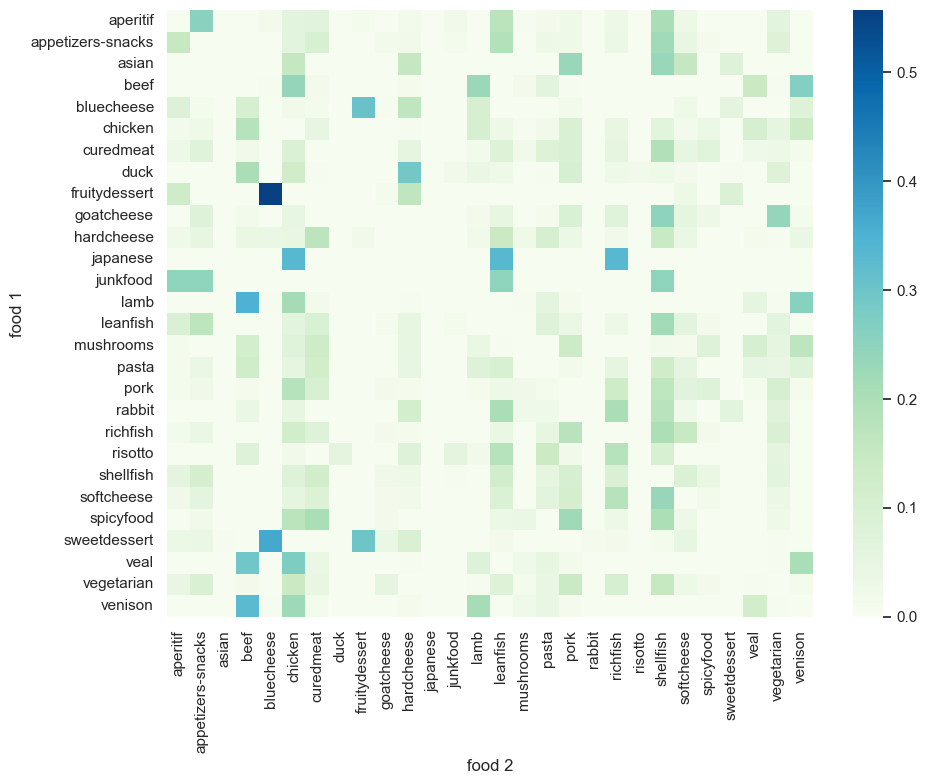

In [74]:
fig=plt.figure(figsize=(10, 8))

table = pd.pivot_table(data=coocc, values="count", columns="food 2", index="food 1")
np.fill_diagonal(table.values, 0)
table = table.div(table.sum(axis=1), axis=0)
#table = table / table.sum(axis=0)

sns.heatmap(table, cmap="GnBu", annot=False)

plt.tight_layout()
plt.grid(visible=False)
fig.savefig(FIGURES / "eda/food_coocc.jpg", bbox_inches="tight", dpi=300)

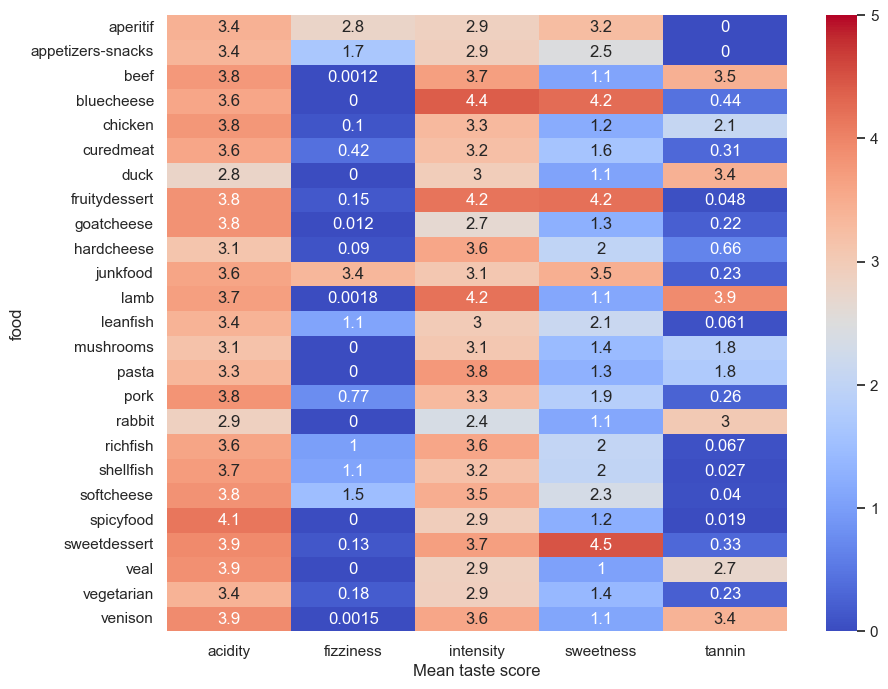

In [75]:
foods = df[['intensity', 'sweetness', 'acidity', 'tannin', 'fizziness', "food"]].copy().explode("food")
foods["food"] = foods["food"].replace(food_mapping)
table = pd.pivot_table(data=foods, values=['intensity', 'sweetness', 'acidity', 'tannin', 'fizziness'], index="food", aggfunc="mean")

fig = plt.figure(figsize=(10, 8))
ax=sns.heatmap(table, cmap="coolwarm", vmin=0, vmax=5, annot=True)
ax.set_xlabel("Mean taste score")
fig.savefig(FIGURES / "eda/food_taste.jpg", dpi=300, bbox_inches="tight")

### Grapes

- Grape names are harmonized, then merged into families to reduce sparsity. EDA uses these merged grapes.
- Section taste before grapes, since inferring tastes based on grapes after first step of pre-processing to be more precise

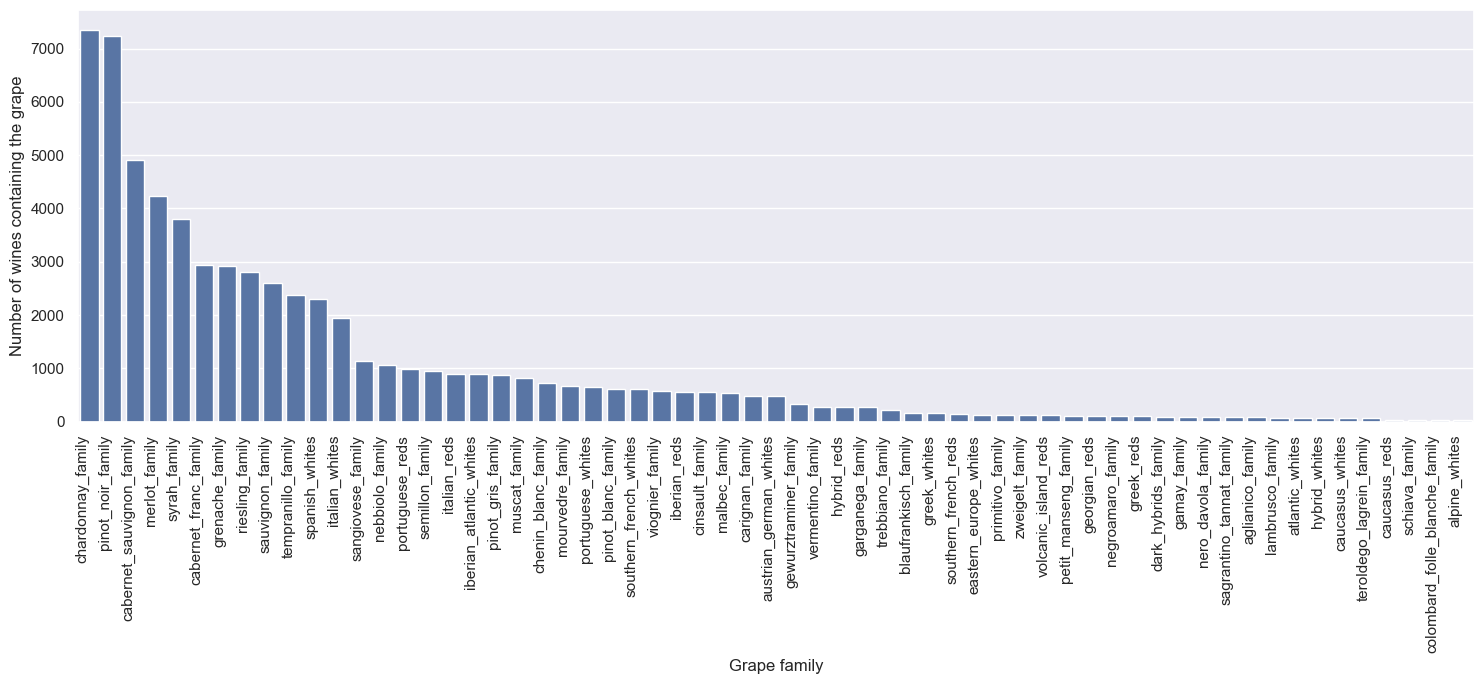

In [76]:
fig=plt.figure(figsize=(15, 7))

grapes_merged = df[["id", "grapes_merged"]].copy()
grapes_merged = grapes_merged.explode("grapes_merged")
# counts = grapes_merged.explode("grapes_merged").value_counts()
counts = grapes_merged.groupby("grapes_merged")["id"].nunique().reset_index()
ax=sns.barplot(data=counts.sort_values("id", ascending=False), y="id", x="grapes_merged")

ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')

ax.set_ylabel("Number of wines containing the grape")
ax.set_xlabel("Grape family")

plt.tight_layout()
fig.savefig(FIGURES / "eda/grapes_distr.jpg", bbox_inches="tight", dpi=300)

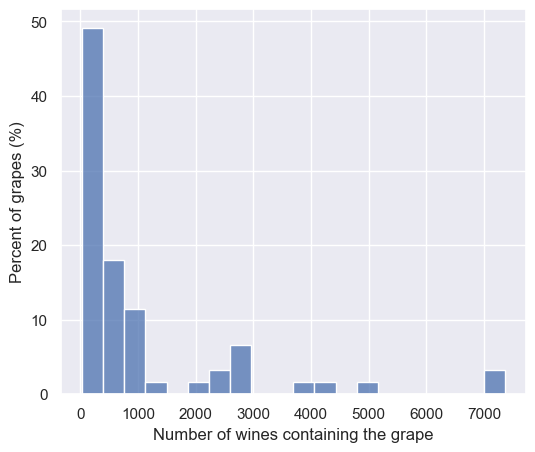

In [77]:
grapes_merged = df[["id", "grapes_merged"]].copy()
grapes_merged = grapes_merged.explode("grapes_merged")
# counts = grapes_merged.explode("grapes_merged").value_counts()
counts = grapes_merged.groupby("grapes_merged")["id"].nunique()

fig = plt.figure(figsize=(6, 5))
ax=sns.histplot(counts, bins=20, stat="percent")
ax.set_ylabel("Percent of grapes (%)")
ax.set_xlabel("Number of wines containing the grape")

fig.savefig(FIGURES / "eda/grapes_step2_distr.jpg", bbox_inches="tight", dpi=300)

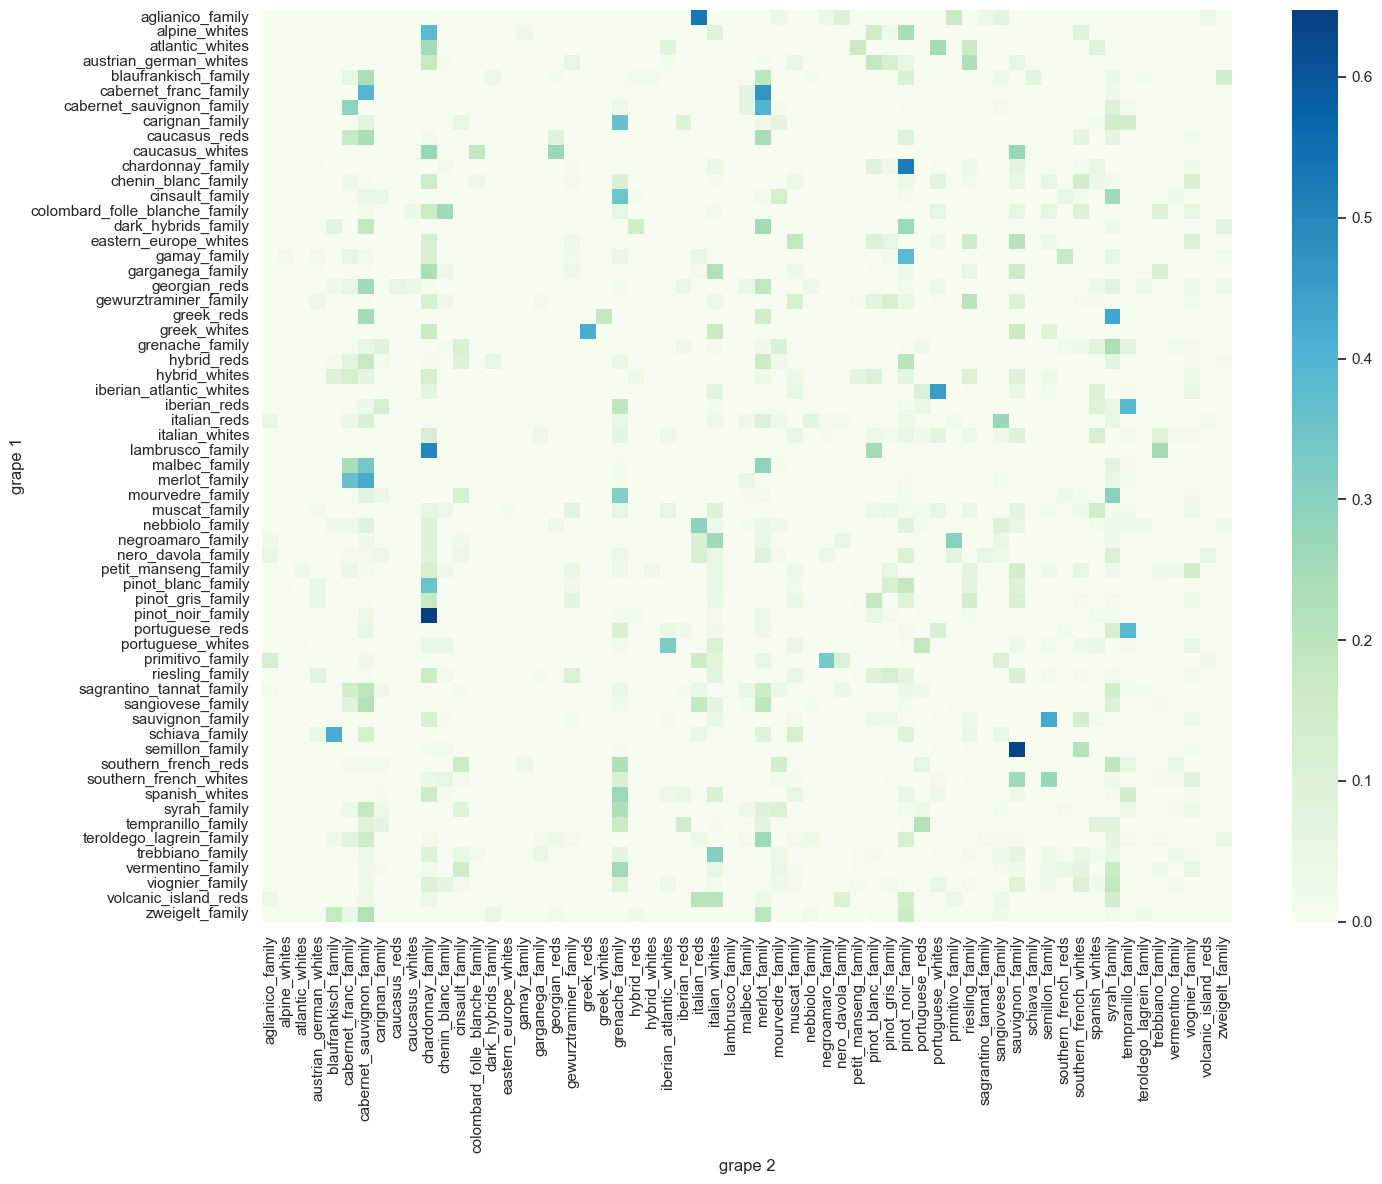

In [78]:
coocc = build_coocc(df[["grapes_merged"]], "grapes_merged")
coocc = coocc.join(coocc["pair"].apply(pd.Series).rename(columns={0:"grape 1", 1:"grape 2"}))

fig=plt.figure(figsize=(15, 12))

table = pd.pivot_table(data=coocc, values="count", columns="grape 2", index="grape 1")
np.fill_diagonal(table.values, 0)
table = table.div(table.sum(axis=1), axis=0)
#table = table / table.sum(axis=0)

sns.heatmap(table, cmap="GnBu", annot=False, xticklabels=True, yticklabels=True)

plt.tight_layout()
plt.grid(visible=True)
fig.savefig(FIGURES / "eda/grapes_coocc.jpg", bbox_inches="tight", dpi=300)

### Pro ratings
Users tend to be less sever then professional. But since pro ratings are sparse, we cant really do much

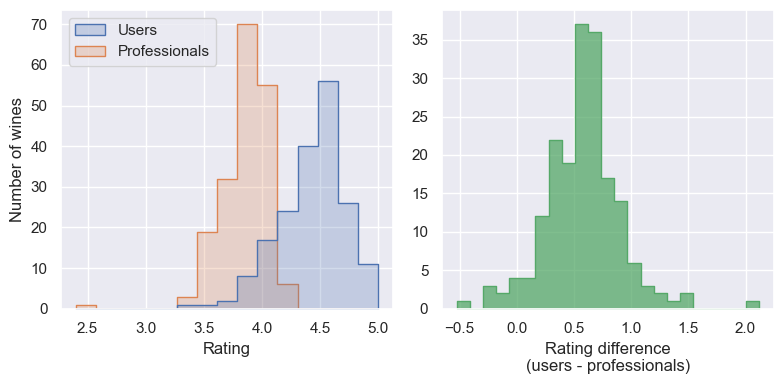

In [79]:
stats = df[["mean_rating", "pro_rating", "price",  "id"]].dropna(subset=["pro_rating"]).rename(columns={"mean_rating":"Users",
                                                                                                       "pro_rating":"Professionals"})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
stats_melt = stats.melt(id_vars=["price"], value_vars=["Users", "Professionals"], var_name="type_rating", value_name="rating")

ax1=sns.histplot(data=stats_melt, x="rating", hue="type_rating", element="step", ax=ax1)
ax1.legend_.set_title(None)
ax1.set_ylabel("Number of wines")
ax1.set_xlabel("Rating")

sns.histplot(stats["Users"] - stats["Professionals"], element="step", color=sns.color_palette("deep")[2], ax=ax2)
ax2.set_xlabel("Rating difference\n(users - professionals)")
ax2.set_ylabel("")

plt.tight_layout()
fig.savefig(FIGURES / "eda/users_pro_rating.jpg", bbox_inches="tight", dpi=300)

### Alcohol

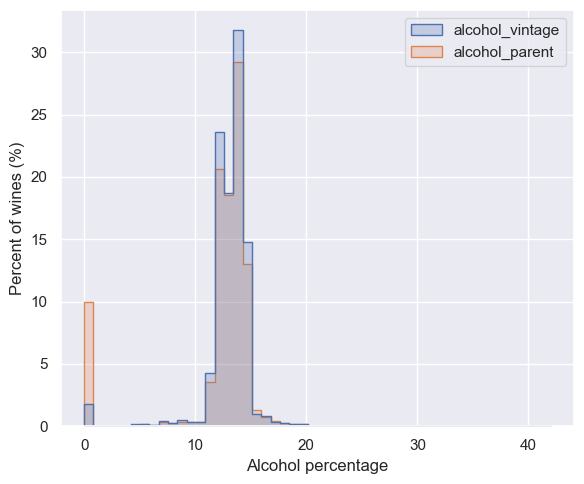

In [80]:
fig = plt.figure(figsize=(6, 5))

alcohols = df_old[["alcohol", "alcohol_parent"]].copy().rename(columns={"alcohol":"alcohol_vintage"})
alcohols = alcohols.melt(value_vars=["alcohol_vintage", "alcohol_parent"], var_name="db", value_name="alcohol_")

ax=sns.histplot(data=alcohols, x="alcohol_", hue="db", stat="percent", bins=50,  element="step", common_norm=False)
ax.set_xlabel("Alcohol percentage")
ax.set_ylabel("Percent of wines (%)")

ax.legend_.set_title(None)

plt.tight_layout()
fig.savefig(FIGURES / "eda/alcohol_distr.jpg", bbox_inches="tight", dpi=300)

In [84]:
alcohols = df_old[["alcohol", "alcohol_parent"]].copy()
alcohols = alcohols[(alcohols["alcohol"] > 0) & (alcohols["alcohol"] < 30) & 
                    (alcohols["alcohol_parent"] > 0) & (alcohols["alcohol_parent"] < 30)]

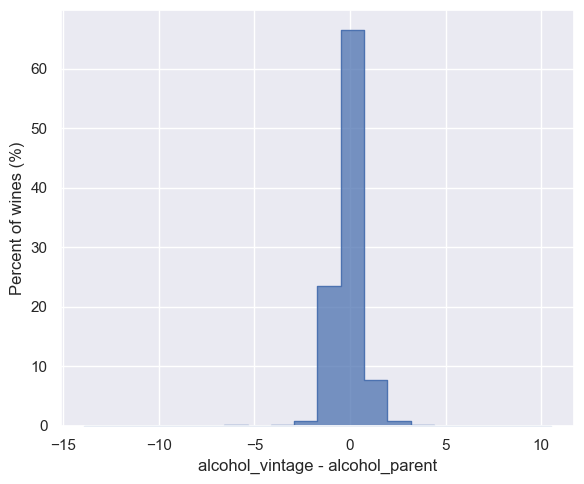

In [85]:
fig = plt.figure(figsize=(6, 5))
ax=sns.histplot(alcohols["alcohol"] - alcohols["alcohol_parent"], bins=20, stat="percent", element="step")
ax.set_ylabel("Percent of wines (%)")
ax.set_xlabel("alcohol_vintage - alcohol_parent")
plt.tight_layout()
fig.savefig(FIGURES / "eda/diff_alcohol.jpg", bbox_inches="tight", dpi=300)

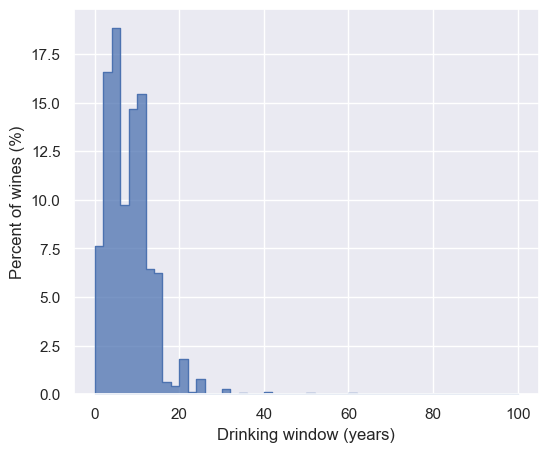

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))

diff = df_old[["window_end_year", "window_start_year", "price"]].copy()
diff["Observed"] =  df_old["window_end_year"] - df_old["window_start_year"]

sns.histplot(diff["Observed"], ax=ax, bins=50, element="step", stat="percent")
ax.set_xlabel("Drinking window (years)")
ax.set_ylabel("Percent of wines (%)")
plt.savefig(FIGURES / "eda/drinking_window_distr.jpg", bbox_inches="tight", dpi=300)

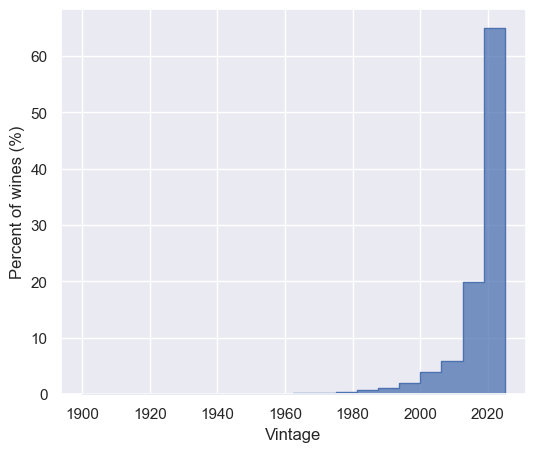

In [87]:
fig=plt.figure(figsize=(6, 5))
ax=sns.histplot(df["year"], bins=20, stat="percent", element="step")
ax.set_xlabel("Vintage")
ax.set_ylabel("Percent of wines (%)")

fig.savefig(FIGURES / "eda/vintage_distr.jpg", bbox_inches="tight", dpi=300)